In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

## Goal 

#### The goal of this lab is to measure the dielectric constant for a paper. 


## Procedure for the Lab  
1. Set up a parallel plate capacitor with paper as the dielectric.  
2. Measure capacitance at different plate separations.  
3. Analyze the relationship between capacitance and inverse distance.  
4. Fit a linear model to the data.  
5. Calculate the dielectric constant using the slope of the fit.

    

In [7]:
# Used to calculate the uncertainity of the capacitor

def getLCRMeterUncertainty(measured, lsb):
    """
    Calculate the uncertainty of a capacitance measurement on the 40 nF range
    of a B&K Precision 878B LCR meter.
    """
    percent_uncertainty = 0.002 * measured
    count_uncertainty = 4 * lsb
    total_uncertainty = percent_uncertainty + count_uncertainty
    return total_uncertainty




## Measurment

In [875]:
# measurment of the 27 deck of paper
distance_27 = 2.55e-3        # 2.55 MILI METER
distance_27_uncertainity = 0.02e-3      # 0.02 MILI METER

# Thickness of 1 sheet of paper
distance = distance_27 / 27
d_distance = distance_27_uncertainity / 27     # Uncertainity

# measurment of the area
length_of_metal_side = 20.4e-2        # 20.4 CENTI METER
d_length_of_metal_side = 0.05e-2      # 0.5 CENTI METER


# Calculate the area of the Alumunium plate
area_of_metal = length_of_metal_side ** 2
d_area_of_metal =  (2 ** (1/2)) * (d_length_of_metal_side / length_of_metal_side)

print(f"{distance}, {d_distance}, {area_of_metal}, {d_area_of_metal}")
f"{distance:.2e}, {d_distance:.2e}, {area_of_metal:.2e}, {d_area_of_metal:.2e}"

9.444444444444446e-05, 7.407407407407408e-07, 0.04161599999999999, 0.0034662097116987633


'9.44e-05, 7.41e-07, 4.16e-02, 3.47e-03'

### Distance of a single sheet of paper 
$$ Distance = (9.44 \pm 0.07) \times  10^{-5} \, \text{m}$$


### Area of Alumnim Plates 
$$ Area = (4.2 \pm 0.3) \times 10^{-2} \, \text{m}^2 $$





## Data Points

In [880]:
# Measured capacitance 

capacitance_data = pd.read_csv("data/lab3_data - Sheet1.csv")

# Add a column for the distance
capacitance_data["Distance"] = capacitance_data["Sheets"] * distance
capacitance_data["d_Distance"] = capacitance_data["Sheets"] * d_distance

# Converting the units of the capacitance and its error to nano farad
capacitance_data["Capacitance (nF)"] = capacitance_data["Capacitance (nF)"] * 1e-9
capacitance_data["dCapacitance (nF)"] *= 1e-9

capacitance_data

,Sheets,Capacitance (nF),dCapacitance (nF),Distance,d_Distance
0,1,2.707100e-09,1.900000e-11,0.000094,7.407407e-07
1,2,1.591000e-09,1.100000e-11,0.000189,1.481481e-06
2,3,1.378100e-09,9.800000e-12,0.000283,2.222222e-06
3,4,1.202400e-09,8.600000e-12,0.000378,2.962963e-06
4,5,1.088900e-09,7.800000e-12,0.000472,3.703704e-06
5,7,9.071000e-10,6.500000e-12,0.000661,5.185185e-06
6,9,7.745000e-10,5.600000e-12,0.000850,6.666667e-06
7,11,6.740000e-10,4.900000e-12,0.001039,8.148148e-06
8,13,5.625000e-10,4.100000e-12,0.001228,9.629630e-06
9,15,5.341000e-10,3.900000e-12,0.001417,1.111111e-05


### Visualizing the scatter of our data points with their associaataed errors 

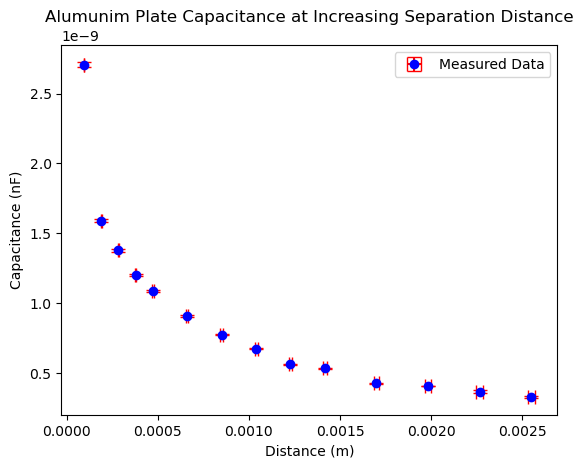

In [882]:
x = capacitance_data["Distance"]
y = capacitance_data["Capacitance (nF)"]
y_err = capacitance_data["dCapacitance (nF)"]
x_err = capacitance_data["d_Distance"]

plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

plt.xlabel(r"Distance (m)")
plt.ylabel("Capacitance (nF)")
plt.title("Alumunim Plate Capacitance at Increasing Separation Distance")
plt.legend()
plt.show()


### The Expression for the Capacitance of a Parallel Plate Capacitor

The expression for the capacitance of a parallel plate capacitor with a dielectric between the plates is given by:

$$
C = \frac{\kappa \epsilon_0 A}{d}
$$

### Understanding the Relationship

Since $\kappa$, $\epsilon_0$, and $A$ are constants, the capacitance follows the relationship:

$$
C =  \frac{m}{d}
$$



Now, we will plot the capacitance data against the inverse of the distance to determine if there is a linear relationship.


In [884]:
# Add a column for the distance inverted

capacitance_data["Distance_inverted"] = 1 / capacitance_data["Distance"]
capacitance_data["d_Distance_inverted"] = (capacitance_data["d_Distance"] / capacitance_data["Distance"]) * capacitance_data["Distance_inverted"]

capacitance_data.head()

,Sheets,Capacitance (nF),dCapacitance (nF),Distance,d_Distance,Distance_inverted,d_Distance_inverted
0,1,2.707100e-09,1.900000e-11,0.000094,7.407407e-07,10588.235294,83.044983
1,2,1.591000e-09,1.100000e-11,0.000189,1.481481e-06,5294.117647,41.522491
2,3,1.378100e-09,9.800000e-12,0.000283,2.222222e-06,3529.411765,27.681661
3,4,1.202400e-09,8.600000e-12,0.000378,2.962963e-06,2647.058824,20.761246
4,5,1.088900e-09,7.800000e-12,0.000472,3.703704e-06,2117.647059,16.608997


### Error Propagation for Inverting a Quantity


$$
z = \frac{1}{x}
$$

then the propagated uncertainty in \( z \) is given by:

$$
\delta z = \frac{\delta x}{x} * {z}
$$




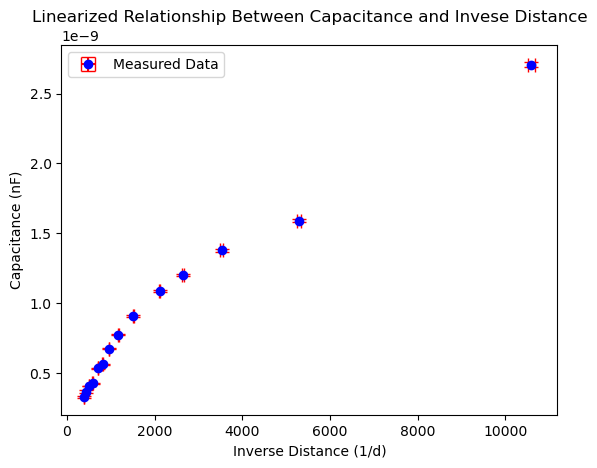

In [886]:
# Extracting data
x = capacitance_data["Distance_inverted"]
y = capacitance_data["Capacitance (nF)"]
y_error = capacitance_data["dCapacitance (nF)"]
x_error = capacitance_data["d_Distance_inverted"]

# Plot 
plt.errorbar(x, y, xerr=x_error, yerr=y_error, fmt="o", capsize=5, markersize=6, color="blue", ecolor="red", label="Measured Data")

plt.xlabel(r"Inverse Distance (1/d)")
plt.ylabel("Capacitance (nF)")
plt.title("Linearized Relationship Between Capacitance and Invese Distance")
plt.legend()

# Show plot
plt.show()

#### Our data points appear most linear in the interval between 0 and 2000. Therefore, we will filter our data to include only these values to ensure our linear model is as accurate as possible.


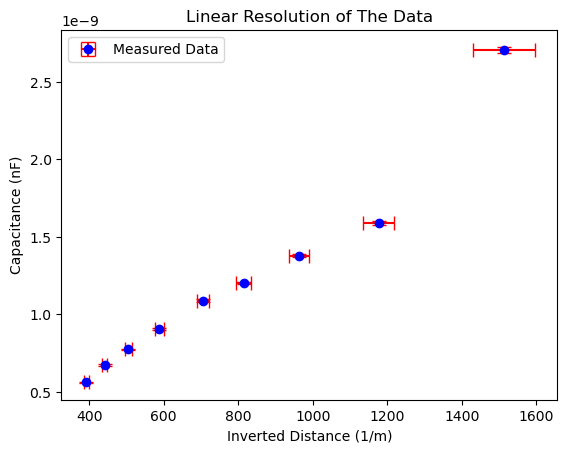

In [942]:
# Limit x-axis values to below 2000
x = x[x < 2000]

# Adjust corresponding y and error values to match the new x length
y = capacitance_data["Capacitance (nF)"].head(len(x))
y_err = capacitance_data["dCapacitance (nF)"].head(len(x))
x_err = capacitance_data["d_Distance_inverted"].head(len(x))

# Plot error bars with styling similar to the previous radiation plot
plt.errorbar(x, y, xerr=x_err, yerr=y_err, fmt="o", capsize=5, markersize=6, color="blue", ecolor="red", label="Measured Data")


# Labels and title
plt.xlabel(r"Inverted Distance (1/m)")
plt.ylabel("Capacitance (nF)")
plt.title("Linear Resolution of The Data")
plt.legend()
plt.show()


 

## Dominant Source of Uncertainty

#### The dominant source of uncertainty is that the relationship between capacitance and inverted distance does not strictly follow a linear trend as the inverted distance increases. In this plot, we have determined that the data points appear most skewed for larger values of the inverted distance. To improve the quality of our regression fit, we have filtered the data points where the graph appears most linear. However, this selection was done visually, making it prone to significant errors and biases.


### Now we are going to fit a regression line where we would use scipy.curve_fit to estimate the slope and its error. 

In [892]:
linear_model = lambda x, A, B: A * x + B

# having a best fit line
parameters, errors = curve_fit( linear_model, x, y, sigma = y_err, absolute_sigma=True )

slope = parameters[0]
intercept = parameters[1]
print(f"{slope:.2e}, {intercept:.2e}")

1.52e-12, -1.22e-11


### Estimated Slope
Since the estimated uncertainiy for the slope and intercept are so small we can consider them negligable. 
The estimated slope:


Estimated slope and uncertainity = 

$$
1.52 \times 10^{-12}, \quad -0.12 \times 10^{-12}
$$$$
$
$$


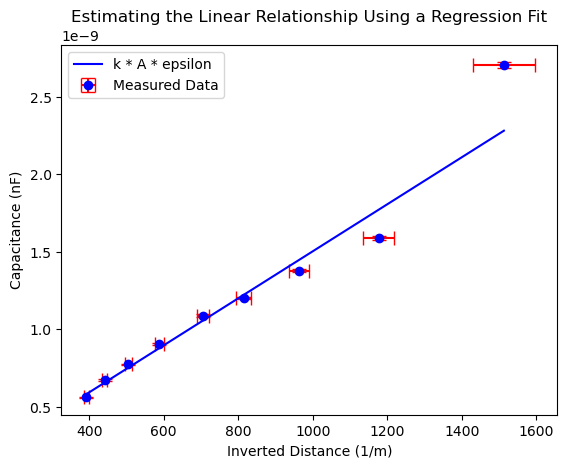

In [948]:
# Limit x-axis values to below 2000
x = x[x < 2000]

# Adjust corresponding y and error values to match the new x length
y = capacitance_data["Capacitance (nF)"].head(len(x))
y_err = capacitance_data["dCapacitance (nF)"].head(len(x))
x_err = capacitance_data["d_Distance_inverted"].head(len(x))

# Plot error bars with styling similar to the previous radiation plot
plt.errorbar(x, y, xerr=x_err, yerr=y_err, fmt="o", capsize=5, markersize=6, color="blue", ecolor="red", label="Measured Data")

plt.xlabel(r"Inverted Distance (1/m)")
plt.ylabel("Capacitance (nF)")
plt.title("Estimating the Linear Relationship Using a Regression Fit")
plt.legend()


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="k * A * epsilon", color='blue')


plt.legend(); 
plt.show()

### Derivation of k

We start with the capacitance equation:

$$
C = \frac{\kappa \epsilon_0 A}{d}
$$

Rearrange for  $\kappa$

$$
\kappa = \frac{C d}{\epsilon_0 A}
$$

Since the slope is defined as:

$$
m = \kappa \epsilon_0 A
$$

Solving for k


$$
\kappa = \frac{m}{\epsilon_0 A}
$$

In [914]:
kappa = slope / ( (8.854e-12) * area_of_metal)

 ### Error Propagation for k 

The dielectric constant is calculated as:

$$
\kappa = \frac{m}{\epsilon_0 A}
$$

Applying uncertainty propagation:

$$
\left( \frac{\Delta \kappa}{\kappa} \right)^2 = \left( \frac{\Delta m}{m} \right)^2 + \left( \frac{\Delta A}{A} \right)^2
$$



$$
\Delta \kappa = \kappa \sqrt{\left( \frac{\Delta m}{m} \right)^2 + \left( \frac{\Delta A}{A} \right)^2}
$$


since the uncertainity for the slope is small we can consider it negligable

In [921]:
kappa_error = kappa * np.sqrt(( d_area_of_metal / area_of_metal) ** 2)

kappa, kappa_error

(4.117140521591639, 0.342917927248401)

### Estimated Dielectric constant for a paper  

$$
\kappa = 4.12 \pm 0.34
$$
$


## Comparison to the Accepted Value

#### Based on online sources, such as [this website](https://www.engineeringtoolbox.com/relative-permittivity-d_1660.html), the permittivity constant of hard paper appears to be around 4.5. Other sources indicate that the dielectric constant of paper typically falls between 2 and 4, possibly depending on the type of paper. Since our result, including its uncertainty, falls within this range, we can conclude that our estimate is reasonable and acceptable.


## Connection to physics 

#### By applying the principles of electrostatics to measure the dielectric constant of paper, we observed that the capacitance of two parallel plates decreases inversely with their separation distance. We also found that the permittivity constant of paper is significantly greater than that of air. This means that inserting a non-conductive material between the plates increases the capacitance of the parallel plate capacitor. Additionally, we saw that the LCR meter measures capacitance by applying a potential difference and determining the resulting charge storage between the plates.



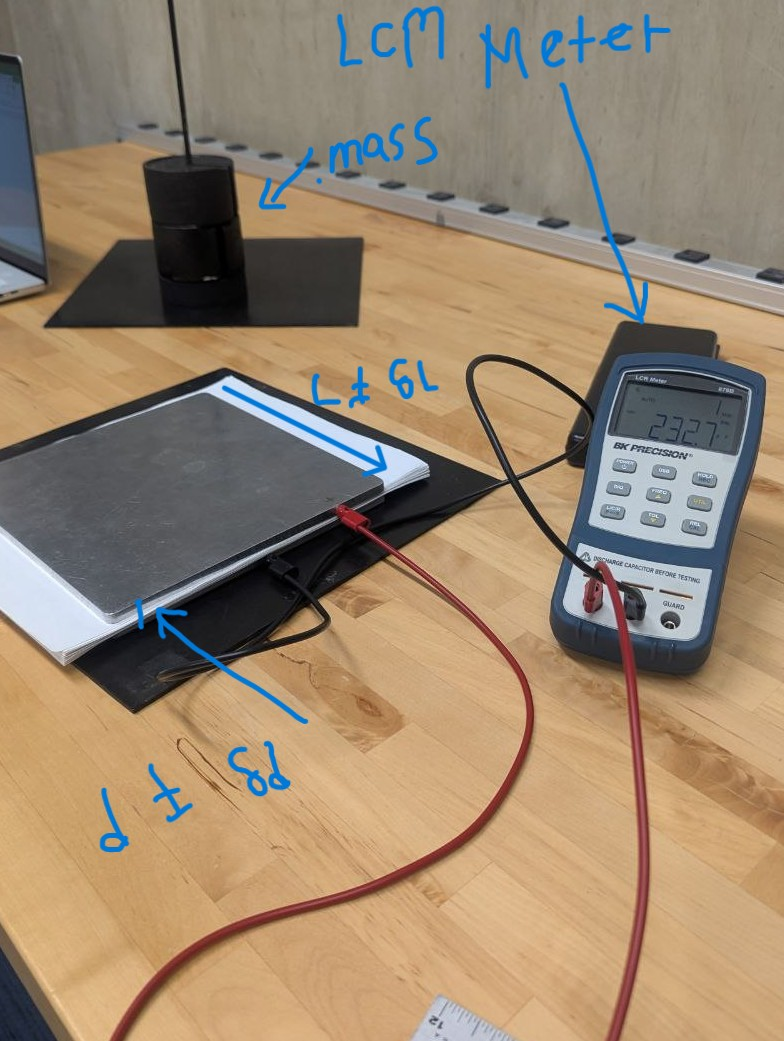
